[[0.00000e+00]
 [1.25000e-02]
 [2.50000e-02]
 ...
 [5.49625e+01]
 [5.49750e+01]
 [5.49875e+01]]
1


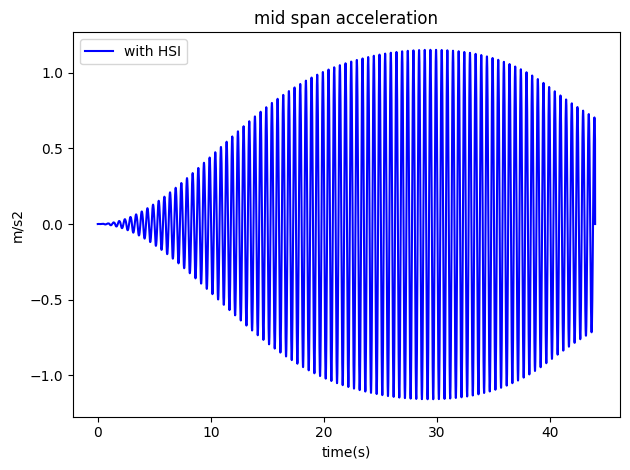

In [1]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import timeit
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 3 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

ModalMass = linearMass*length/2


def curve1(x):
    return np.sin(np.pi*x/length)

def curve2(x):
    return np.sin(2*np.pi*x/length)

def curve3(x):
    return np.sin(3*np.pi*x/length)

#ped
pedmass = 73.85     #kg
peddamp = 0.3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
meanvelocity = 1.25
pedBodyF= 2 #Hz


#ped
#kped1=(2*np.pi*pedBodyF)**2*pedmass
#cped1 = (2*np.pi*pedBodyF)*2*peddamp*pedmass
kped1 = 14110
cped1 = 612.5
#generating random pace and phase


# Given values
xrb = [0]  # Initial positions
hht=0.01

# Generate time steps
t = np.arange(0, (length + 5) / meanvelocity, hht)  # Time array

# Generate the matrix
xrb = np.array([xrb + meanvelocity * time for time in t])
numped = xrb.shape[1]  #number of pedestrians
print(xrb) 
print(numped)

#pedpace = np.random.normal(2, 0.173, numped)
#pedphase = np.random.uniform(0, 2*np.pi, numped)


func_list=[curve1,curve2,curve3] #list of functions for the modal mass calculation
#modalmass = [modal_mass]


modalmass = [ModalMass,ModalMass,ModalMass]
mped = np.repeat(pedmass,numped)  #np.array([pedmass])
cped = np.repeat(cped1,numped)    #np.array([cped1])
kped = np.repeat(kped1,numped)
pedmass = np.repeat(pedmass,numped)  #np.array([pedmass])
pedpace = np.repeat(pedpace,numped)  #np.array([pedpace])
pedphase = np.repeat(pedphase,numped)  #np.array([pedphase])

#bridge
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12



#initial possition vector.......formultiple ped all these would become matrices



Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,  )                   #modes


Human = Pedestrian(
         mass = mped,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = xrb,
         velocity = meanvelocity,
         
         iSync=0)

_,_,ddu_hsi = Newmarksuper_HSIsocial(Human,Bridge,numped,numbers,length,hht,meanvelocity,mped,kped,cped,xrb,modalmass,func_list)

accn_hsi = accdyn_super_social(Bridge,ddu_hsi,x_interested,modalmass,func_list)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)

#absolute_max = max(xrb, key=abs)
t =np.arange(0, (length + 5) / meanvelocity, hht)
#plt.plot(t,accn , label ="without HSI" ,color='r')
plt.plot(t,accn_hsi,label ="with HSI",color='b')
#plt.plot(t,accn_EQ,label ="with EQ",color='g')
#plt.plot(t, accn, label='with MF',color='r')
#plt.plot(6.97, 2.81, 'ro', label='Predicted peak using constant equivalent FRF')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
plt.tight_layout()
#plt.savefig("All In one", format='pdf', dpi=300)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)'''

[[0.00000e+00]
 [1.34000e-02]
 [2.68000e-02]
 ...
 [5.49668e+01]
 [5.49802e+01]
 [5.49936e+01]]
1


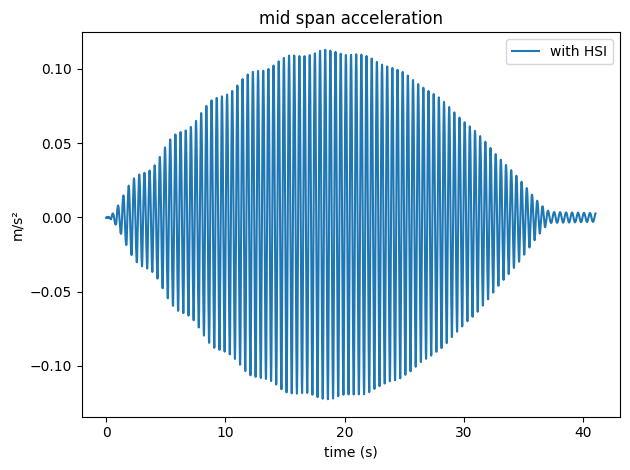

In [2]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import timeit
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 3 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

ModalMass = linearMass*length/2


def curve1(x):
    return np.sin(np.pi*x/length)

def curve2(x):
    return np.sin(2*np.pi*x/length)

def curve3(x):
    return np.sin(3*np.pi*x/length)

def curve4(x):
    return np.sin(4*np.pi*x/length)

#ped
pedmass = 73.85     #kg
peddamp = 0.3 
pedBodyF= 2 #Hz   
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
meanvelocity = 1.34 #np.random.normal(loc=1.34, scale=0.26, size=numped)



#ped
#kped1=(2*np.pi*pedBodyF)**2*pedmass
#cped1 = (2*np.pi*pedBodyF)*2*peddamp*pedmass
kped1 = 0#14110
cped1 = 0#612.5
#generating random pace and phase


# Given values
xrb = [0]  # Initial positions
hht=0.01

# Generate time steps
t = np.arange(0, (length + 5) / meanvelocity, hht)  # Time array

# Generate the matrix
xrb = np.array([xrb + meanvelocity * time for time in t])
numped = xrb.shape[1]  #number of pedestrians
print(xrb) 
print(numped)

# number of pedestrians
numped = xrb.shape[1]

# --- MASS: Lognormal with mean 73.85, SD 15.68 in kg ---
mean_m = 73.85
sd_m   = 15.68

sigma2_log = np.log(1.0 + (sd_m / mean_m)**2)
sigma_log  = np.sqrt(sigma2_log)
mu_log     = np.log(mean_m) - 0.5 * sigma2_log

# pedmass array: (numped,)
pedmass = np.random.lognormal(mean=mu_log, sigma=sigma_log, size=numped)


pedpace = np.random.normal(2, 0.173, numped)
pedphase = np.random.uniform(0, 2*np.pi, numped)


func_list=[curve1,curve2,curve3] #list of functions for the modal mass calculation
#modalmass = [modal_mass]


modalmass = [ModalMass,ModalMass,ModalMass]
mped = np.repeat(pedmass,numped)  #np.array([pedmass])
cped = np.repeat(cped1,numped)    #np.array([cped1])
kped = np.repeat(kped1,numped)
pedmass = np.repeat(pedmass,numped)  #np.array([pedmass])
pedpace = np.repeat(pedpace,numped)  #np.array([pedpace])
pedphase = np.repeat(pedphase,numped)  #np.array([pedphase])

#bridge
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12



#initial possition vector.......formultiple ped all these would become matrices



Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,  )                   #modes


Human = Pedestrian(
         mass = mped,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = xrb,
         velocity = meanvelocity,
         
         iSync=0)

# --- state-space solution ---
q_hist, qd_hist, qdd_hist = solve_HSI_state_space2(
    Human, Bridge,
    mped, kped, cped,
    xrb,           # xrb_over_time, shape (n_steps, numped)
    length,
    modalmass,
    numbers,       # N_bridge
    numped,
    t,
    func_list,
    hht            # dt
)

# Now qdd_hist plays the role of ddu_hsi in your old code
ddu_hsi = qdd_hist.T

accn_hsi = accdyn_super_social(Bridge, ddu_hsi, x_interested, modalmass, func_list)

plt.plot(t, accn_hsi, label="with HSI")
plt.title("mid span acceleration")
plt.xlabel("time (s)")
plt.ylabel("m/s²")
plt.legend()
plt.tight_layout()
plt.show()

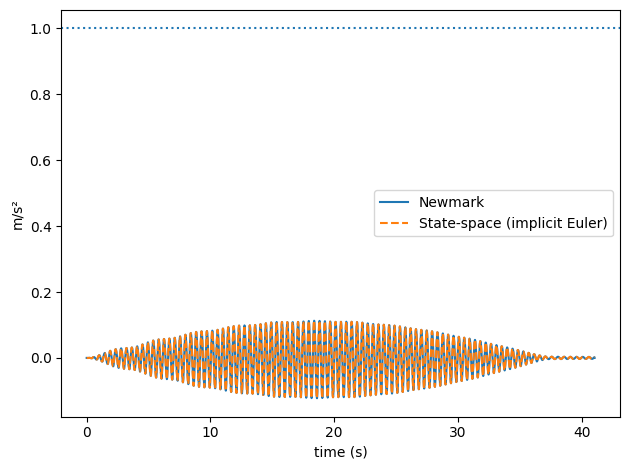

In [3]:
# Newmark solution
_, _, ddu_newmark = Newmarksuper_HSIsocial(
    Human, Bridge,
    numped, numbers, length, hht, meanvelocity,
    mped, kped, cped,
    xrb, modalmass, func_list
)
acc_newmark = accdyn_super_social(Bridge, ddu_newmark, x_interested, modalmass, func_list)

# State-space solution
q_hist, qd_hist, qdd_hist = solve_HSI_state_space2(
    Human, Bridge,
    mped, kped, cped,
    xrb, length,
    modalmass,
    numbers,
    numped,
    t,
    func_list,
    hht
)
acc_ss = accdyn_super_social(Bridge, qdd_hist.T, x_interested, modalmass, func_list)

plt.plot(t, acc_newmark, label="Newmark")
plt.plot(t, acc_ss, '--', label="State-space (implicit Euler)")
plt.axhline(y=1, linestyle=':')
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("m/s²")
plt.tight_layout()
plt.show()


In [1]:
import socialforce
import imageio
from IPython.display import HTML, display
import numpy as np
import torch
from socialforcefunctions import initial_state_corridor_for_1,bounded_gamma_sample1
import pandas as pd
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt

length = 50.0
width = 2.0
hht =0.01
meanvelocity = 1.34
stddev = 0.26

t =np.arange(0, (length + 5) / meanvelocity, hht)
totalTimeSteps = np.size(t)
print(np.size(t))

tocity = 1 #bounded_gamma_sample1(16.7,12.0,0.0,67.0)
print(tocity)
outcity = 0 #bounded_gamma_sample1(9.4,4.1,1.0,21.0)
print(outcity)


initial_state = initial_state_corridor_for_1(tocity,outcity,length,width,meanvelocity,stddev)
   


upper_wall = torch.stack([torch.linspace(0, length, 1000), torch.full((1000,), width)], -1)
lower_wall = torch.stack([torch.linspace(0, length, 1000), torch.full((1000,), 0)], -1)
ped_space = socialforce.potentials.PedSpacePotential([upper_wall, lower_wall])

#ped_ped = socialforce.potentials.PedPedPotential()
#ped_ped = socialforce.potentials.PedPedPotentialDiamond(sigma=0.5)
ped_ped = socialforce.potentials.PedPedPotentialDiamond(sigma=0.5, asymmetry_angle=-20.0)
#ped_ped = socialforce.potentials.PedPedPotential2D()


simulator = socialforce.Simulator(ped_ped=ped_ped, ped_space=ped_space,
                                  oversampling=1, delta_t=hht)
simulator.integrator = socialforce.simulator.PeriodicBoundary(
        simulator.integrator, x_boundary=[0, +length])

with torch.no_grad():
    states_sf = simulator.run(initial_state, totalTimeSteps)
    '''
    with socialforce.show.track_canvas(ncols=2, figsize=(12, 2), tight_layout=False) as (ax1, ax2):
    socialforce.show.states(ax1, states_sf[0:1], monochrome=True)
    socialforce.show.space(ax1, ped_space)
    ax1.text(0.1, 0.1, '$t = 0s$', transform=ax1.transAxes)
    ax1.set_xlim(0, +length)

    socialforce.show.states(ax2, states_sf[249:250], monochrome=True)
    socialforce.show.space(ax2, ped_space)
    ax2.text(0.1, 0.1, '$t = 20s$', transform=ax2.transAxes)
    ax2.set_xlim(0, length)'''
    #print(states_sf[0:1])
    #   print(states_sf[249:250])
    #__________________________________________________________________end of crowd generator_________________________________________________________________________




    #__________________________________________________________________Extracting the coordinates_______________________________________________________________________

# Extract the number of pedestrians and timesteps
num_timesteps = len(states_sf)
#print(states_sf.size())
num_pedestrians = states_sf[0].shape[0]
#print("Number of pedestrians:", num_pedestrians)
#print("Number of timesteps:", num_timesteps)

# Create an array to store the variations in coordinates
x_coords = np.zeros((num_timesteps, num_pedestrians))
y_coords = np.zeros((num_timesteps, num_pedestrians))

# Fill in the matrix
for t in range(num_timesteps):
    x_coords[t, :] = states_sf[t][:, 0].numpy()  # Extract x-coordinates
    y_coords[t, :] = states_sf[t][:, 1].numpy()  # Extract y-coordinates

#__________________________________________________________________end of Extracting the coordinates_______________________________________________________________________
'''import os
import imageio.v2 as imageio  # or just `import imageio` if you prefer

# -----------------------------
# Make frames and save as GIF
# -----------------------------
frames = []
step = 5   # use every 5th timestep to keep GIF smaller (change if you like)

for k in range(0, num_timesteps, step):
    fig, ax = plt.subplots(figsize=(6, 2))
    ax.scatter(x_coords[k, :], y_coords[k, :], s=10)
    ax.set_xlim(0, length)
    ax.set_ylim(0, width)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(f"t = {k * hht:.2f} s")
    plt.tight_layout()

    # Convert current figure to an array
    fig.canvas.draw()

    # Get width and height
    w, h = fig.canvas.get_width_height()

    # Get RGBA buffer from the canvas
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    buf = buf.reshape((h, w, 4))  # (height, width, 4 channels)

    # Drop alpha channel → RGB only
    frame = buf[:, :, :3]

    frames.append(frame)
    plt.close(fig)

# duration per frame in seconds (approx physical time = hht * step)
imageio.mimsave("walking_peds.gif", frames, duration=hht * step)

# -----------------------------
# Display in notebook
# -----------------------------
display(HTML('<img src="walking_peds.gif">'))'''



4105
1
0


'import os\nimport imageio.v2 as imageio  # or just `import imageio` if you prefer\n\n# -----------------------------\n# Make frames and save as GIF\n# -----------------------------\nframes = []\nstep = 5   # use every 5th timestep to keep GIF smaller (change if you like)\n\nfor k in range(0, num_timesteps, step):\n    fig, ax = plt.subplots(figsize=(6, 2))\n    ax.scatter(x_coords[k, :], y_coords[k, :], s=10)\n    ax.set_xlim(0, length)\n    ax.set_ylim(0, width)\n    ax.set_xlabel("x [m]")\n    ax.set_ylabel("y [m]")\n    ax.set_title(f"t = {k * hht:.2f} s")\n    plt.tight_layout()\n\n    # Convert current figure to an array\n    fig.canvas.draw()\n\n    # Get width and height\n    w, h = fig.canvas.get_width_height()\n\n    # Get RGBA buffer from the canvas\n    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)\n    buf = buf.reshape((h, w, 4))  # (height, width, 4 channels)\n\n    # Drop alpha channel → RGB only\n    frame = buf[:, :, :3]\n\n    frames.append(frame)\n  

[[0.00000000e+00]
 [1.16794109e-02]
 [2.33594142e-02]
 ...
 [4.79213181e+01]
 [4.79329948e+01]
 [4.79446716e+01]]
1


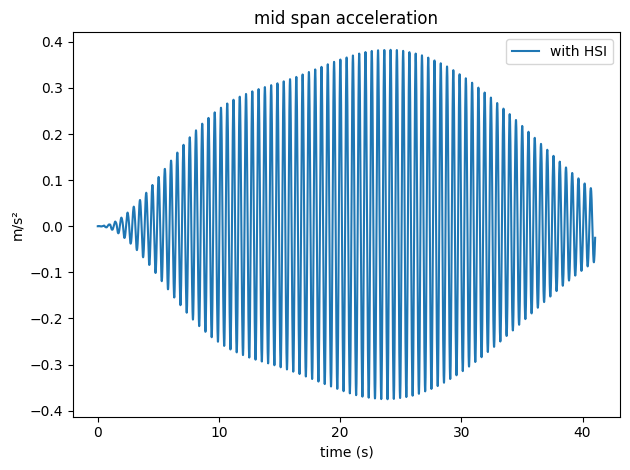

In [8]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import timeit
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 4 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

ModalMass = linearMass*length/2


def curve1(x):
    return np.sin(np.pi*x/length)

def curve2(x):
    return np.sin(2*np.pi*x/length)

def curve3(x):
    return np.sin(3*np.pi*x/length)

def curve4(x):
    return np.sin(4*np.pi*x/length)

#ped
pedmass = 73.85     #kg
peddamp = 0.3 
pedBodyF= 2 #Hz   
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
meanvelocity = 1.34 #np.random.normal(loc=1.34, scale=0.26, size=numped)



#ped
#kped1=(2*np.pi*pedBodyF)**2*pedmass
#cped1 = (2*np.pi*pedBodyF)*2*peddamp*pedmass
kped1 = 14110
cped1 = 612.5
#generating random pace and phase


# Given values
#xrb = [0]  # Initial positions
hht=0.01

# Generate time steps
t = np.arange(0, (length + 5) / meanvelocity, hht)  # Time array

# Generate the matrix
xrb = x_coords #np.array([xrb + meanvelocity * time for time in t])
numped = xrb.shape[1]  #number of pedestrians
print(xrb) 
print(numped)

# number of pedestrians
numped = xrb.shape[1]

# --- MASS: Lognormal with mean 73.85, SD 15.68 in kg ---
mean_m = 73.85
sd_m   = 15.68

sigma2_log = np.log(1.0 + (sd_m / mean_m)**2)
sigma_log  = np.sqrt(sigma2_log)
mu_log     = np.log(mean_m) - 0.5 * sigma2_log

# pedmass array: (numped,)
pedmass = np.random.lognormal(mean=mu_log, sigma=sigma_log, size=numped)


pedpace = np.random.normal(2, 0.173, numped)
pedphase = np.random.uniform(0, 2*np.pi, numped)


func_list=[curve1,curve2,curve3,curve4] #list of functions for the modal mass calculation
#modalmass = [modal_mass]


modalmass = [ModalMass,ModalMass,ModalMass,ModalMass]
mped = np.repeat(pedmass,numped)  #np.array([pedmass])
cped = np.repeat(cped1,numped)    #np.array([cped1])
kped = np.repeat(kped1,numped)
pedmass = np.repeat(pedmass,numped)  #np.array([pedmass])
pedpace = np.repeat(pedpace,numped)  #np.array([pedpace])
pedphase = np.repeat(pedphase,numped)  #np.array([pedphase])

#bridge
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12



#initial possition vector.......formultiple ped all these would become matrices



Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,  )                   #modes


Human = Pedestrian(
         mass = mped,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = xrb,
         velocity = meanvelocity,
         
         iSync=0)

# --- state-space solution ---
q_hist, qd_hist, qdd_hist, A_hist, B_hist = solve_HSI_state_space_full(
    Human, Bridge,
    mped, kped, cped,
    xrb,           # xrb_over_time, shape (n_steps, numped)
    length,
    modalmass,
    numbers,       # N_bridge
    numped,
    t,
    func_list,
    hht,
    return_AB=True            # dt
)

# Now qdd_hist plays the role of ddu_hsi in your old code
ddu_hsi = qdd_hist.T

accn_hsi = accdyn_super_social(Bridge, ddu_hsi, x_interested, modalmass, func_list)

plt.plot(t, accn_hsi, label="with HSI")
plt.title("mid span acceleration")
plt.xlabel("time (s)")
plt.ylabel("m/s²")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
k = 100  # timestep index

print("Time:", t[k])
print("A_k:\n", A_hist[k])
print("B_k:\n", B_hist[k])


Time: 1.0
A_k:
 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [-1.57921716e+02 -1.60337158e-02 -2.39073642e-02 -3.16103069e-02
   1.06547247e+01 -1.26012956e-01 -6.96006443e-04 -1.03779310e-03
  -1.37216960e-03

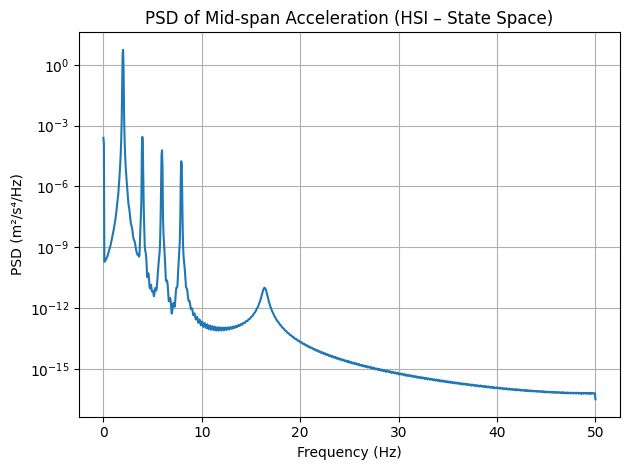

In [27]:
from scipy.signal import welch

fs = 1.0 / hht   # sampling frequency (Hz)

f_psd, Pxx = welch(
    accn_hsi,
    fs=fs,
    window="hann",
    nperseg=2048,       # you can tune this (1024–4096 typical)
    noverlap=1024,     # 50% overlap
    detrend="constant"
)

# Plot PSD
plt.figure()
plt.semilogy(f_psd, Pxx)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (m²/s⁴/Hz)")
plt.title("PSD of Mid-span Acceleration (HSI – State Space)")
plt.grid(True)
plt.tight_layout()
plt.show()
